# Лабораторная работа № 2

# Визуальный анализ данных

**Цель работы:** изучить программные средства, используемые для визуализации наборов данных

Выполним анализ набора данных «Характеристики автомобилей». Набор представляет собой данные о технических характеристиках автомобилей различных производителей (расход топлива, мощность, вес, ускорение и прочие). Набор данных подходит для обучения моделей регрессии, моделей классификации. Набор данных включает следующие атрибуты:
- **mpg** – расход топлива (miles per gallon);
- **cylinders** – цилиндры;
- **displacement** – пробег;
- **horsepower** – мощность двигателя в л.с.;
- **weight** – вес;
- **acceleration** – ускорение;
- **model** – год выпуска;
- **origin** – происхождение;
- **car** – название модели;
- **owners** – количество владельцев.

# 1. Импортируем необходимые библиотеки

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
%matplotlib inline

# 2. Импортируем набор данных из файла auto_result.csv и поместим его в объект DataFrame

In [2]:
data = pd.read_csv("auto_result.csv")
data.head(10)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model,origin,car,owners
0,18.0,8,307,130.0,3504,12.0,70,1,chevrolet chevelle malibu,19434
1,15.0,8,350,165.0,3693,11.5,70,1,buick skylark 320,51913
2,18.0,8,318,150.0,3436,11.0,70,1,plymouth satellite,49432
3,16.0,8,304,150.0,3433,12.0,70,1,amc rebel sst,42076
4,17.0,8,302,140.0,3449,10.5,70,1,ford torino,10365
5,15.0,8,429,198.0,4341,10.0,70,1,ford galaxie 500,46435
6,14.0,8,454,220.0,4354,9.0,70,1,chevrolet impala,16515
7,14.0,8,440,215.0,4312,8.5,70,1,plymouth fury iii,15944
8,14.0,8,455,225.0,4425,10.0,70,1,pontiac catalina,46995
9,15.0,8,390,190.0,3850,8.5,70,1,amc ambassador dpl,45266


# 3. Получим сводную информацию по датафрейму

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    int64  
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model         398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car           398 non-null    object 
 9   owners        398 non-null    int64  
dtypes: float64(3), int64(6), object(1)
memory usage: 31.2+ KB


# 4. Визуализация количественных признаков

Для представления распределения простого количественного признака подходит обычная гистограмма. Построим гистограмму для признака "owners" (количество владельцев).

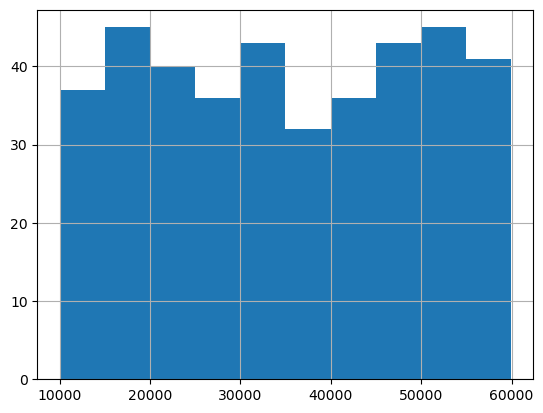

In [4]:
data['owners'].hist();

> На гистограмме видно, что количество владельцев (owners) распределено достаточно равномерно в диапазоне от 10 000 до 60 000. Нет ярко выраженных пиков или провалов — все столбцы примерно одинаковой высоты. Это объясняется тем, что столбец owners был создан с помощью генератора случайных чисел (np.random.randint) в ЛР1, поэтому значения распределены равномерно.

Изменим размер фигуры и применим метод hist() для визуализации распределения нескольких признаков

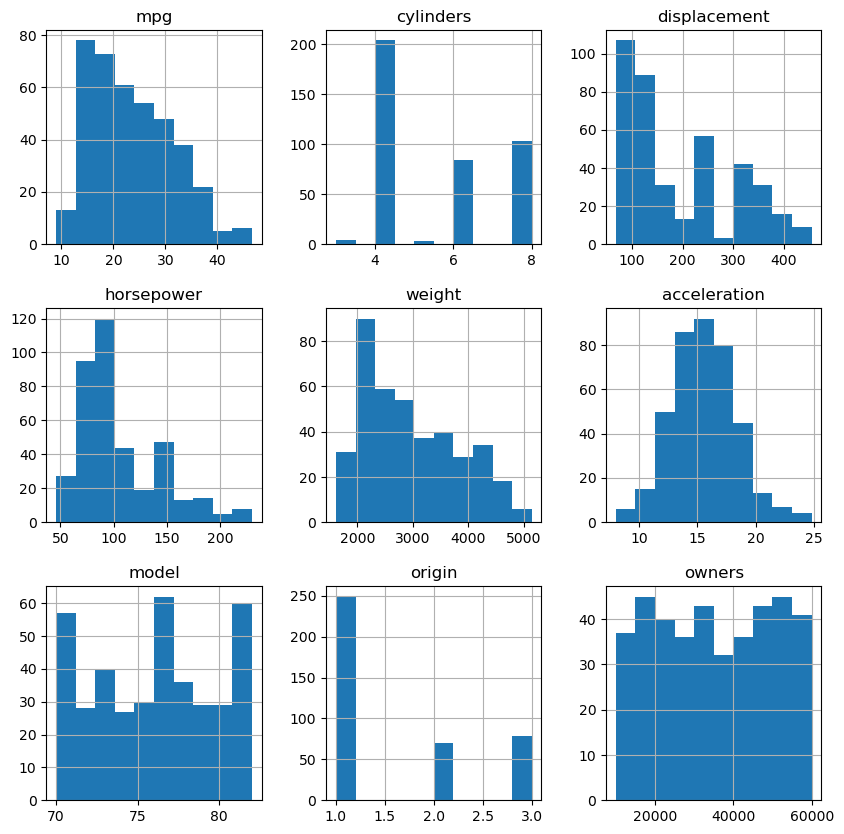

In [5]:
data.hist(figsize=(10, 10));

> По гистограммам видно, что большинство автомобилей в датасете имеют 4 цилиндра, расход топлива (mpg) чаще всего находится в диапазоне 15–30, а мощность (horsepower) — в диапазоне 50–120 л.с. Признаки displacement, horsepower и weight имеют правостороннюю асимметрию — большинство значений сконцентрировано в левой части. Признак acceleration близок к нормальному распределению. Признак origin показывает, что большинство автомобилей произведены в США (origin = 1). Признак owners распределён равномерно, так как был сгенерирован случайным образом.

Аналогичный тип графика можно получить с использованием matplotlib

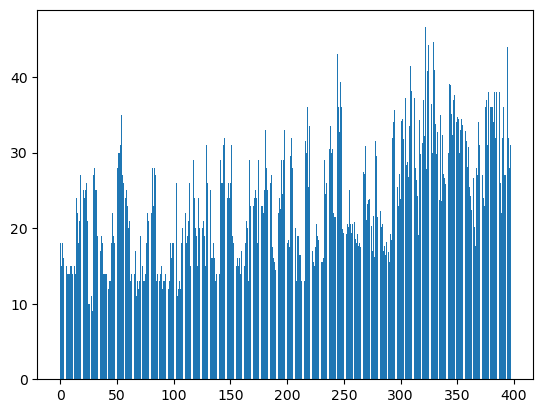

In [6]:
plt.bar(data.index, data['mpg'])
plt.show()

> На столбчатом графике представлено значение расхода топлива (mpg) для каждого автомобиля в датасете. Видно, что в начале датасета (индексы 0–100) преобладают автомобили с низким расходом топлива (10–20 mpg), а ближе к концу (индексы 300–400) — с более высоким (25–40 mpg). Это объясняется тем, что автомобили в датасете отсортированы по году выпуска (model), и более новые автомобили, как правило, более экономичные.

Если нужен график распределения, то нужно выполнить дополнительные расчеты

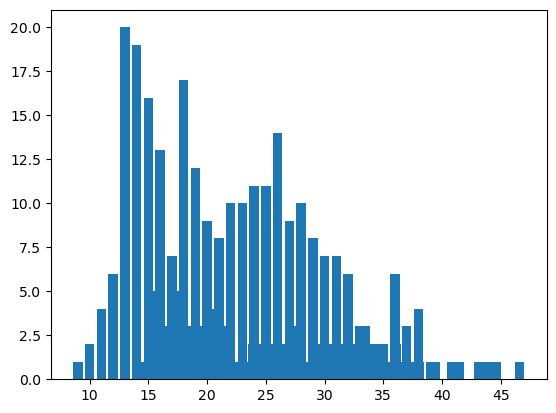

In [7]:
hist = data['mpg'].value_counts()
plt.bar(hist.index, hist);

> На графике распределения видно, что наиболее часто встречающиеся значения расхода топлива (mpg) находятся в диапазоне 13–15 mpg — это пик распределения (около 20 автомобилей). Второй заметный пик — в районе 25–27 mpg. Распределение имеет правостороннюю асимметрию: большинство автомобилей имеют расход от 10 до 30 mpg, а автомобили с расходом выше 35 mpg встречаются редко.

Построение диаграммы типа "ящик с усами" (boxplot) для отдельного признака. По диаграмме можно определить медиану, квартили, интерквартильный размах, выбросы.

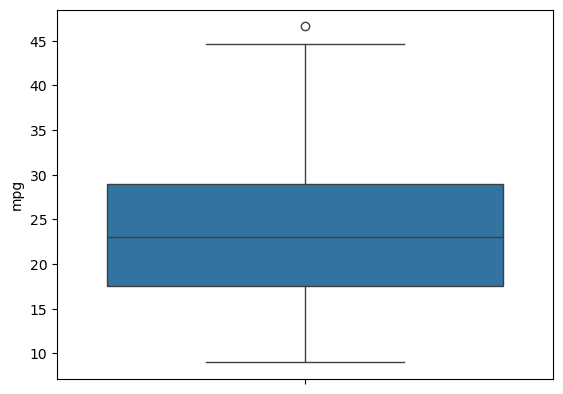

In [8]:
sns.boxplot(data['mpg']);

> На диаграмме «ящик с усами» для признака mpg видно, что медиана расхода топлива составляет примерно 23 mpg (черта внутри коробки). Интерквартильный размах (коробка) находится примерно от 17.5 до 29 mpg — в этом диапазоне сосредоточено 50% всех автомобилей. Верхний ус достигает примерно 45 mpg, нижний — около 9 mpg. Также видна одна точка-выброс сверху (около 46.6 mpg) — это автомобиль с нетипично высокой экономичностью.

Ниже представлен код и результат построения графиков для анализа трёх годов выпуска с максимальным суммарным расходом топлива (mpg).

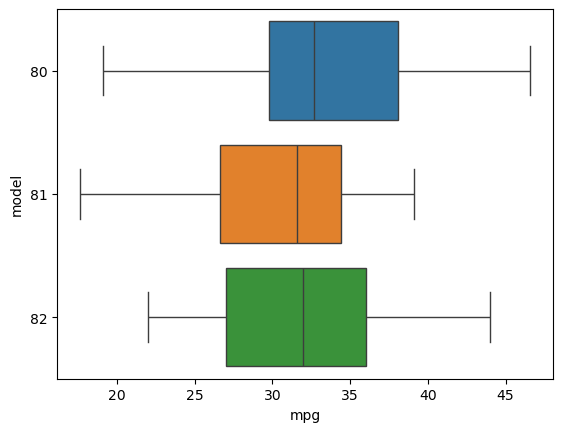

In [9]:
top_data = data[['model', 'mpg']]
top_data = top_data.groupby('model').sum()
top_data = top_data.sort_values('mpg', ascending=False)
top_data = top_data[:3].index.values

filtered = data[data.model.isin(top_data)].copy()
filtered['model'] = filtered['model'].astype(str)

sns.boxplot(y='model', x='mpg',
            data=filtered, hue='model');

> На диаграмме boxplot представлены три года выпуска с максимальным суммарным расходом топлива: 80, 81 и 82. Автомобили 82-го года имеют наибольший разброс значений mpg (от ~18 до ~45), при этом медиана составляет около 32 mpg. У автомобилей 80-го года медиана самая высокая — около 34 mpg, но разброс меньше. Автомобили 81-го года имеют медиану около 30 mpg. В целом все три года характеризуются достаточно экономичными автомобилями (mpg > 25), что объясняется тем, что в более поздние годы выпускались более экономичные модели.

# 5. Визуализация категориальных признаков

Типичным категориальным признаком в анализируемом наборе данных является «Происхождение» (origin). Ниже представлены графики типа countplot() из библиотеки seaborn, которые строят гистограммы не по сырым данным, а по рассчитанному количеству разных значений признака.

In [10]:
# подсчёт количества автомобилей по регионам
data['origin'].value_counts()

origin
1    249
3     79
2     70
Name: count, dtype: int64

> В датасете преобладают автомобили из США (origin = 1) — 249 штук. Автомобилей из Японии (origin = 3) — 79, из Европы (origin = 2) — 70. Таким образом, более 60% всех автомобилей в выборке — американского производства.

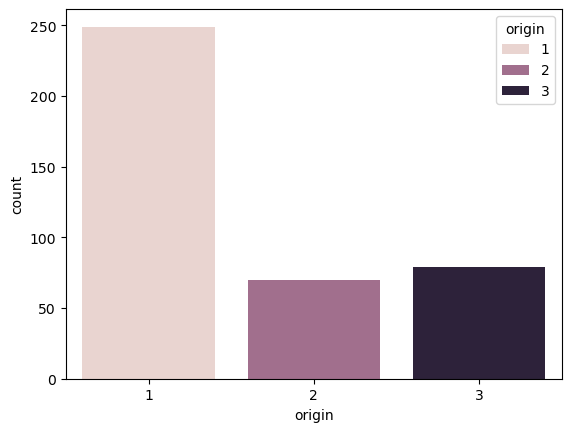

In [11]:
sns.countplot(data, x='origin', hue='origin')
plt.show()

> На графике countplot наглядно видно, что автомобили из США (origin = 1) значительно преобладают в датасете — около 250 штук. Автомобили из Европы (origin = 2) и Японии (origin = 3) представлены примерно в равном количестве — около 70 и 80 штук соответственно. Визуально график полностью совпадает с результатами подсчёта value_counts(), который мы выполнили выше.

Гистограмма пяти самых популярных годов выпуска (model)

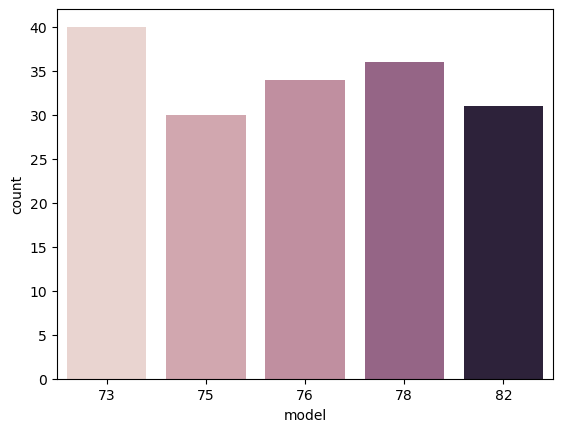

In [12]:
# гистограмма пяти "популярных" годов выпуска
sns.countplot(data[data['model'].isin(data['model'].value_counts().head(5).index)],
              x='model', hue='model', legend=False)
plt.show()

> На гистограмме представлены пять самых популярных годов выпуска по количеству автомобилей в датасете. Лидирует 73-й год — 40 автомобилей. За ним идут 78-й (36), 76-й (34), 82-й (31) и 75-й (30). Это означает, что в 73-м году в датасете представлено наибольшее число моделей автомобилей.

Гистограмма для всех годов выпуска (model)

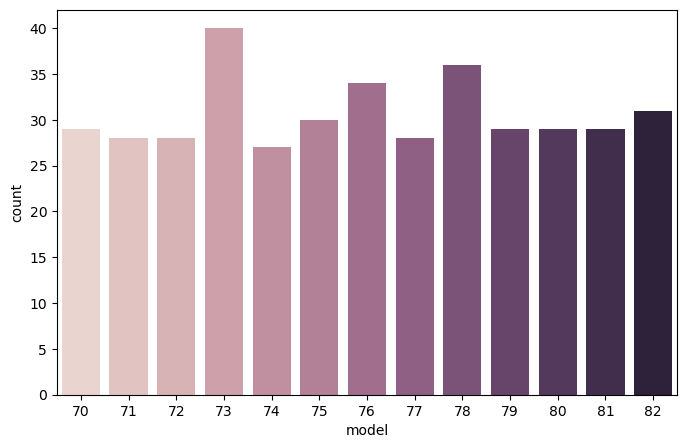

In [13]:
fig = plt.subplots(figsize=(8, 5))
sns.countplot(data, x='model', hue='model', legend=False)
plt.show()

> На гистограмме представлено распределение автомобилей по всем годам выпуска (с 70 по 82). Наибольшее количество автомобилей приходится на 73-й год (40 штук) и 78-й год (36 штук). Наименьшее — на 74-й год (27 штук). В целом количество автомобилей по годам распределено относительно равномерно, без резких перепадов, что говорит о сбалансированности датасета по признаку года выпуска.

Построим столбчатую диаграмму с использованием matplotlib для отображения количества автомобилей по годам выпуска, отсортированных по популярности

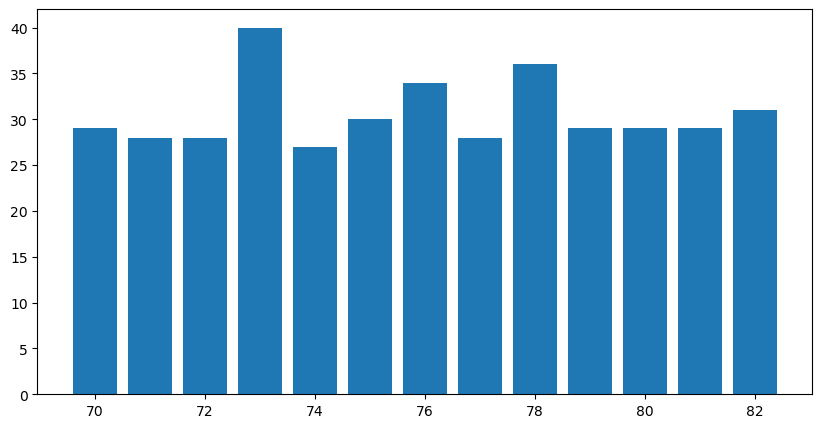

In [14]:
fig = plt.subplots(figsize=(10, 5))
hist = data['model'].value_counts()
plt.bar(hist.index, hist);

> На столбчатой диаграмме года выпуска отсортированы по убыванию количества автомобилей. Лидирует 73-й год (40 автомобилей), на втором месте — 78-й (36). Наименьшее количество автомобилей приходится на 74-й год (27). В отличие от предыдущего графика countplot, здесь столбцы расположены по порядку годов, так как value_counts() отсортировал данные, а plt.bar() отобразил их по числовому индексу.

# 6. Визуализация взаимосвязанных признаков

Рассмотрим пример, демонстрирующий сравнение распределений показателей, связанных с характеристиками двигателя. Ниже представлен код для отбора требуемых показателей.

In [15]:
data.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model', 'origin', 'car', 'owners'],
      dtype='object')

Отберем числовые признаки, связанные с характеристиками двигателя

In [16]:
feats = ['displacement', 'horsepower', 'weight', 'acceleration']
feats

['displacement', 'horsepower', 'weight', 'acceleration']

> Для анализа взаимосвязей были отобраны четыре признака, связанных с характеристиками двигателя: displacement (объём двигателя), horsepower (мощность), weight (вес) и acceleration (ускорение). Эти признаки взаимосвязаны между собой, так как все они описывают технические характеристики автомобиля и влияют друг на друга.

Построим отдельные гистограммы для нескольких взаимосвязанных признаков

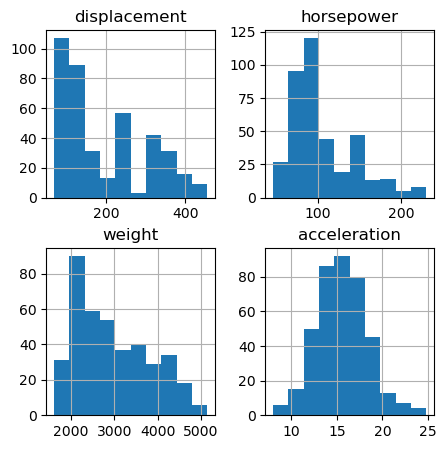

In [17]:
data[feats].hist(figsize=(5, 5));

> На гистограммах видно, что признаки displacement, horsepower и weight имеют похожую форму распределения — правостороннюю асимметрию, где большинство значений сосредоточено в левой части. Это говорит о том, что в датасете преобладают автомобили с небольшим объёмом двигателя, невысокой мощностью и относительно малым весом. Признак acceleration распределён более равномерно и близок к нормальному распределению с пиком в районе 14–16 секунд.

Часто используют попарное сравнение признаков для обеспечения широкого взгляда на набор данных. На диагональных графиках представлены гистограммы распределения отдельного признака, на недиагональных позициях — попарные распределения

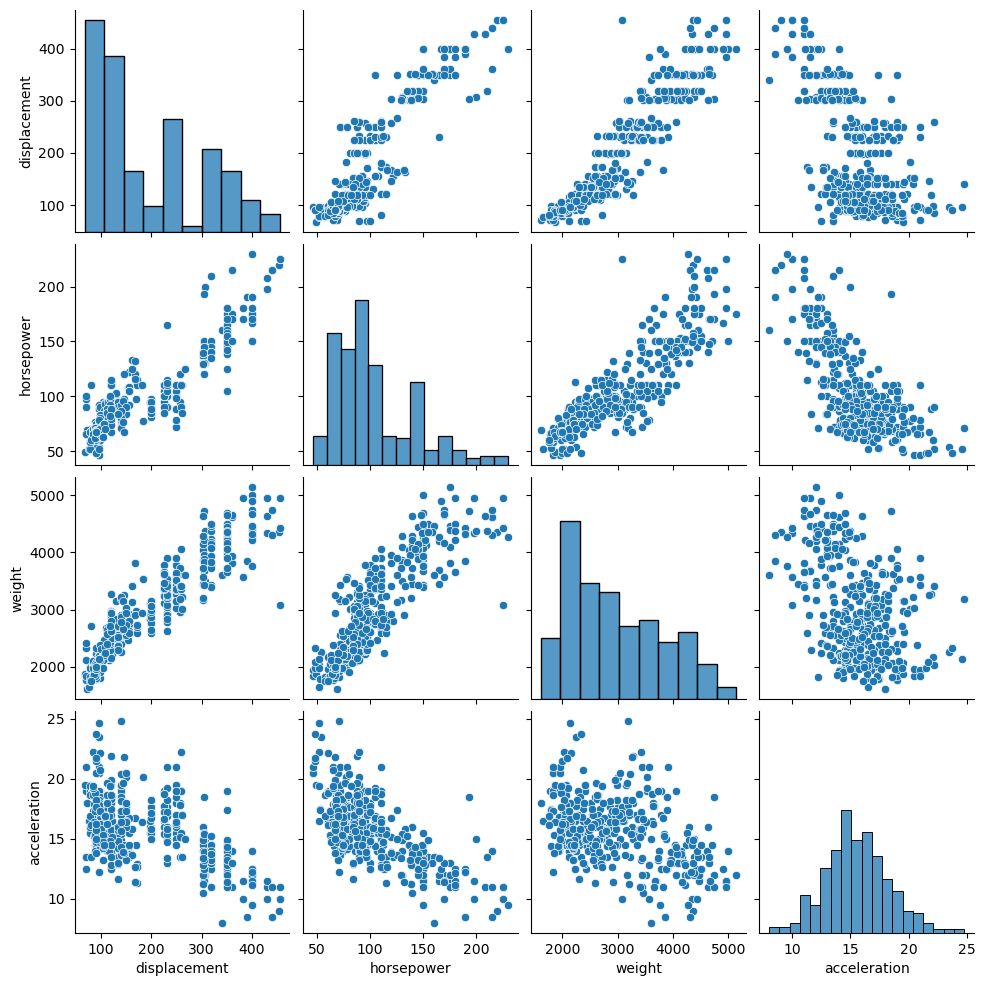

In [18]:
sns.pairplot(data[feats]);

> На матрице попарных распределений видно, что между признаками displacement, horsepower и weight наблюдается сильная положительная связь — точки выстраиваются по диагонали снизу вверх. Это означает, что чем больше объём двигателя, тем выше мощность и тем тяжелее автомобиль. Признак acceleration, наоборот, имеет отрицательную связь с остальными — чем мощнее и тяжелее автомобиль, тем хуже ускорение (больше секунд до разгона). На диагонали расположены гистограммы распределения каждого признака отдельно.

Можно реализовать более сложные графики. Добавим к существующим признакам целевой признак origin (происхождение) и раскрасим разные типы элементов с помощью попарных распределений с отображением подмножеств по регионам.

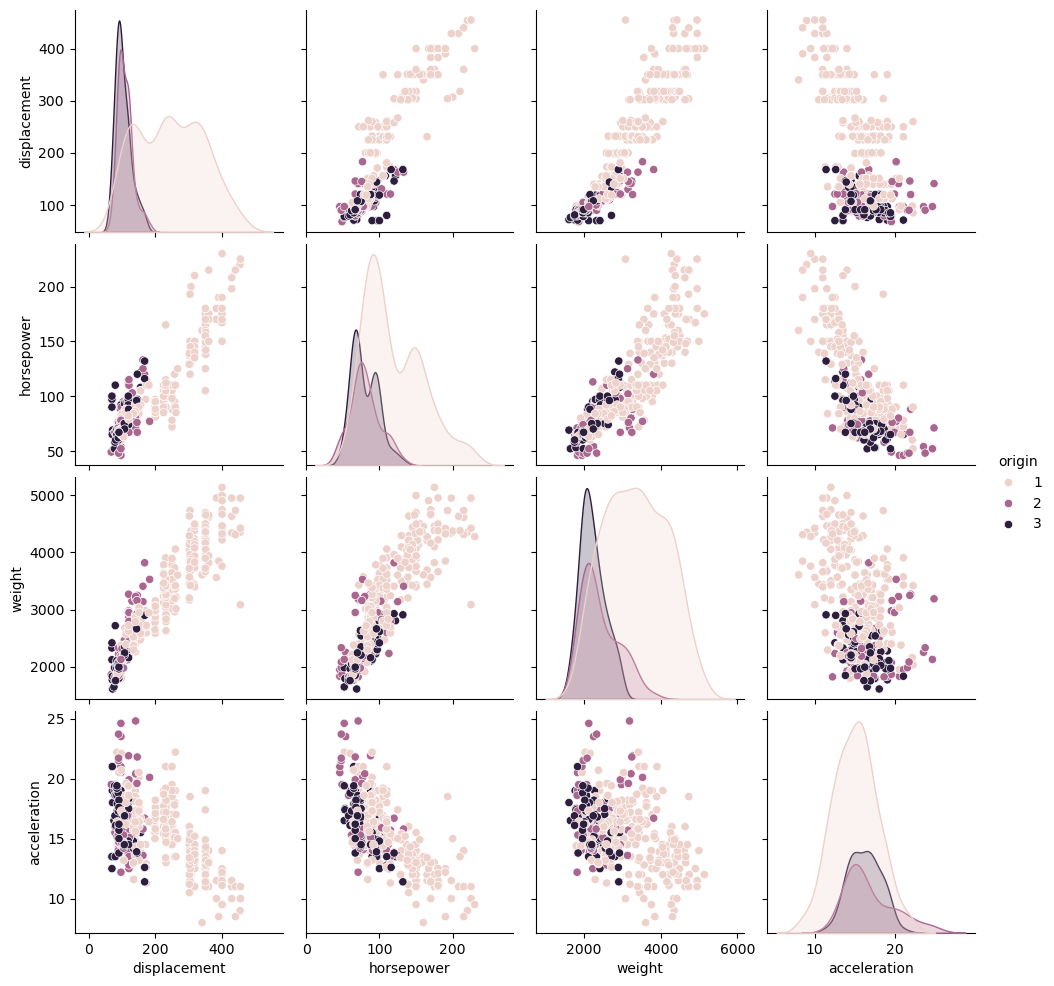

In [19]:
sns.pairplot(data[feats + ['origin']], hue='origin');

> На матрице попарных распределений с разделением по регионам видно чёткое разделение автомобилей. Американские автомобили (origin = 1, светлые точки) имеют наибольший объём двигателя, мощность и вес, но худшее ускорение. Японские автомобили (origin = 3, тёмные точки) — наоборот, самые лёгкие, с маленьким объёмом двигателя и лучшим ускорением. Европейские автомобили (origin = 2) занимают промежуточное положение. На диагональных графиках видно, что распределения для каждого региона заметно отличаются друг от друга.

Использование matplotlib, подписей данных, заголовков. Использование простейших пользовательских цветов

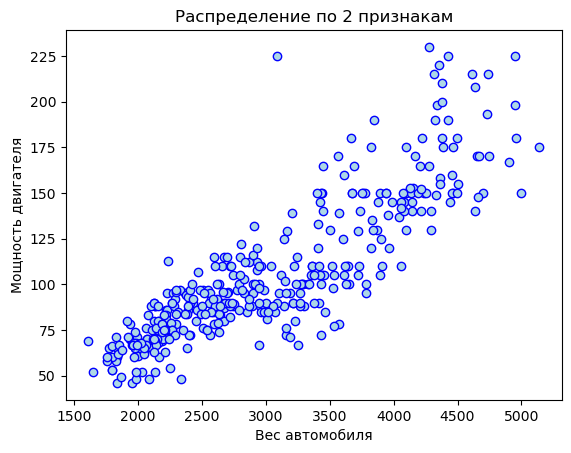

In [20]:
plt.scatter(data['weight'],
            data['horsepower'],
            color='lightblue', edgecolors='blue')
plt.xlabel('Вес автомобиля')
plt.ylabel('Мощность двигателя')
plt.title('Распределение по 2 признакам');

> На точечном графике видна положительная связь между весом автомобиля и мощностью двигателя — чем тяжелее автомобиль, тем выше его мощность. Большинство автомобилей сконцентрировано в диапазоне веса 2000–3500 и мощности 75–125 л.с. Также заметны отдельные точки-выбросы с высокой мощностью (более 200 л.с.).

Раскраска точек в зависимости от региона происхождения автомобиля, добавление легенды

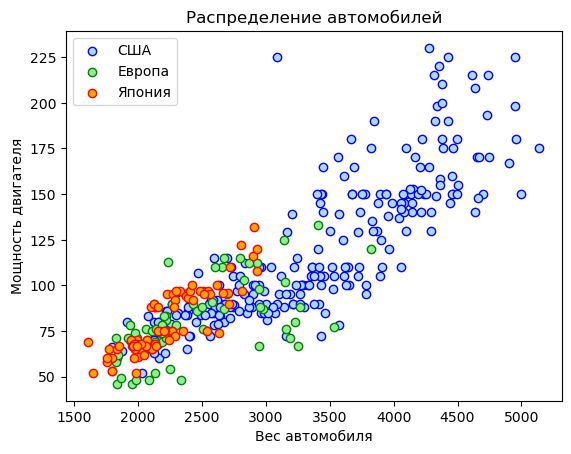

In [21]:
# Американские автомобили
data_us = data[data['origin'] == 1]
# Европейские автомобили
data_eu = data[data['origin'] == 2]
# Японские автомобили
data_jp = data[data['origin'] == 3]

plt.scatter(data_us['weight'],
            data_us['horsepower'],
            color='lightblue',
            edgecolors='blue',
            label='США'
            )
plt.scatter(data_eu['weight'],
            data_eu['horsepower'],
            color='lightgreen',
            edgecolors='green',
            label='Европа'
            )
plt.scatter(data_jp['weight'],
            data_jp['horsepower'],
            color='orange',
            edgecolors='red',
            label='Япония'
            )
plt.xlabel('Вес автомобиля')
plt.ylabel('Мощность двигателя')
plt.title('Распределение автомобилей')
plt.legend();

> На точечном графике с раскраской по регионам чётко видно разделение автомобилей. Американские автомобили (синие) занимают правую верхнюю часть графика — они самые тяжёлые и мощные (вес 3000–5000, мощность 100–225 л.с.). Японские автомобили (оранжевые) расположены в левой нижней части — лёгкие и маломощные (вес 1500–2500, мощность 50–100 л.с.). Европейские автомобили (зелёные) занимают промежуточное положение. Это подтверждает выводы, полученные ранее на pairplot.

# 7. Корреляция признаков

В реальных задачах машинного обучения при первичном анализе данных необходимо выявить корреляции признаков обучающей выборки. В пакете Pandas имеется встроенный инструмент для этого — метод corr() класса DataFrame. Ниже показан фрагмент вывода этой функции.

In [22]:
data.corr(numeric_only=True)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model,origin,owners
mpg,1.000000,-0.775396,-0.804209,-0.778427,-0.831741,0.420289,0.579267,0.563450,0.001769
cylinders,-0.775396,1.000000,0.950722,0.842983,0.896017,-0.505419,-0.348746,-0.562543,-0.012859
displacement,-0.804209,0.950722,1.000000,0.897259,0.932822,-0.543684,-0.370181,-0.609425,-0.026707
horsepower,-0.778427,0.842983,0.897259,1.000000,0.864538,-0.689196,-0.416361,-0.455171,-0.005329
weight,-0.831741,0.896017,0.932822,0.864538,1.000000,-0.417457,-0.306564,-0.581024,-0.040959
acceleration,0.420289,-0.505419,-0.543684,-0.689196,-0.417457,1.000000,0.288137,0.205873,-0.012857
model,0.579267,-0.348746,-0.370181,-0.416361,-0.306564,0.288137,1.000000,0.180662,-0.021003
origin,0.563450,-0.562543,-0.609425,-0.455171,-0.581024,0.205873,0.180662,1.000000,0.056010
owners,0.001769,-0.012859,-0.026707,-0.005329,-0.040959,-0.012857,-0.021003,0.056010,1.000000


> Матрица корреляции имеет размер 9×9. Видно, что некоторые признаки сильно коррелируют между собой: например, displacement и cylinders (0.95), displacement и weight (0.93), horsepower и displacement (0.90), horsepower и weight (0.86). Высокая корреляция означает, что эти признаки тесно связаны и фактически дублируют друг друга. Также видна сильная отрицательная корреляция mpg с weight (-0.83), displacement (-0.80) и horsepower (-0.78) — чем тяжелее и мощнее автомобиль, тем выше расход топлива. Признак owners практически не коррелирует ни с одним другим признаком (значения близки к 0), что ожидаемо, так как он был сгенерирован случайным образом.

Полученная матрица корреляции достаточно большая, и анализировать её вручную трудоёмко. Лучше использовать специальный тип графика — heatmap

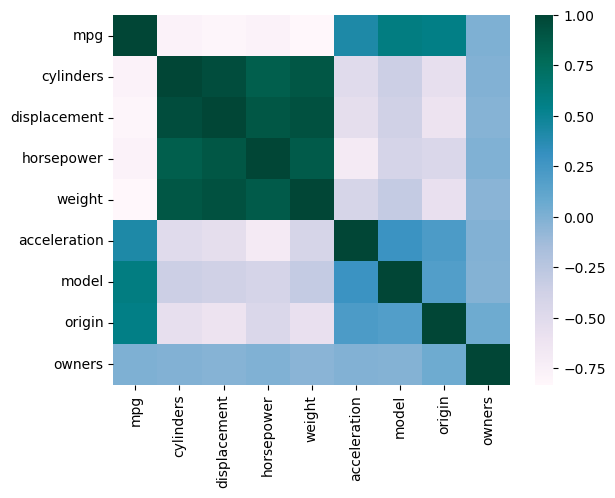

In [23]:
sns.heatmap(data.corr(numeric_only=True), cmap=plt.cm.PuBuGn);

> На тепловой карте корреляции хорошо видны тёмные области — это пары признаков с сильной корреляцией. Наиболее тёмные ячейки наблюдаются между cylinders, displacement, horsepower и weight — эти признаки сильно связаны друг с другом. Также заметна тёмная область отрицательной корреляции у mpg с этими же признаками (светлые ячейки в верхней строке). Признак owners выделяется на карте — его строка и столбец практически однородного светлого цвета, что подтверждает отсутствие связи с другими признаками.

Коррелирующие признаки обычно удаляются и не рассматриваются в процессе обучения. Из карты heatmap видно, что некоторые признаки коррелируют: например, сильная корреляция в парах (cylinders, displacement), (displacement, weight), (horsepower, weight). Из таких пар можно удалить один признак

In [24]:
data_uncorr = data.drop(feats, axis=1)
data_uncorr.columns

Index(['mpg', 'cylinders', 'model', 'origin', 'car', 'owners'], dtype='object')

> После удаления коррелирующих признаков (displacement, horsepower, weight, acceleration) в датафрейме осталось 6 столбцов: mpg, cylinders, model, origin, car, owners. Теперь построим heatmap без коррелирующих признаков.

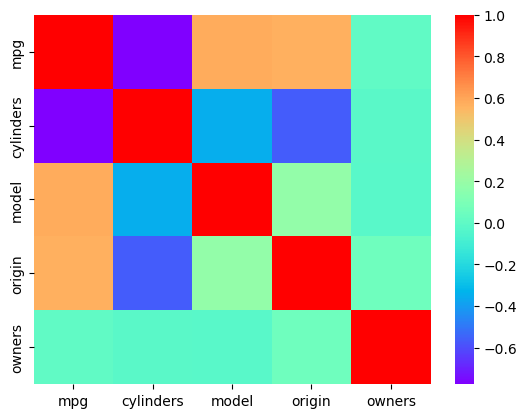

In [25]:
sns.heatmap(data_uncorr.corr(numeric_only=True), cmap=plt.cm.rainbow);

> На обновлённой тепловой карте после удаления коррелирующих признаков видно, что сильных корреляций между оставшимися признаками стало значительно меньше. Наиболее заметная связь — отрицательная корреляция между mpg и cylinders (фиолетовая ячейка, около -0.78): чем больше цилиндров, тем выше расход топлива. Также видна положительная корреляция mpg с origin и model — более новые автомобили и автомобили из Европы/Японии более экономичные. Признак owners по-прежнему не коррелирует с остальными.